In [172]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.collections import LineCollection
from matplotlib.colors import LinearSegmentedColormap
from scipy.interpolate import splprep, splev

OUT_DIR = '/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/FIGURE-2/fig-interactions'
os.makedirs(OUT_DIR, exist_ok=True)

df_interactions = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/n10/clustered-interactions_pt2/cropped_interactions.csv')

df_cluster = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/n10/clustered-interactions_pt2/F15_KMAX3_DMAX4_NMIN1500--/pca-data3-F15-mcmodels4-Kmax3-Dmax4-Nmin1500-05-2026.csv')

df = pd.merge(
    df_interactions,
    df_cluster[['interaction_id', 'Yhat.idt.pca']],
    on='interaction_id',
    how='inner'
)

### CHOSEN G / S PAIRS

Each S is rotated into its G partner's frame (fit on the approach -10..-3 and departure 3..10 frames),
so the two are directly comparable. Red rings mark frames within 1 mm; the strip underneath is the gap over time.

In [173]:
## TRACE HELPERS

CORE_LW = 0.6
HALO_W = 8
N_HALO = 16
HALO_ALPHA = 0.045
HALO_TINT = 0.55
CLIP = (0.0, 1.0)
CONTRAST = 3.0
SMOOTH_WIN = 3
BODY_MIX = 0.30
CONTACT_SIGMA = 1.5
SPLINE_PTS = 600
CONTACT_DIST = 1.0

NODES = ['head', 'body', 'tail']
FRAMES = np.arange(-10, 11)
FIT_MASK = (FRAMES <= -3) | (FRAMES >= 3)

mpl.rcParams.update({'pdf.fonttype': 42, 'ps.fonttype': 42, 'svg.fonttype': 'none',
                     'font.family': 'sans-serif', 'font.sans-serif': ['Arial']})

CMAPS = {1: LinearSegmentedColormap.from_list('t1', ['#b3cfe6', '#4e93c6', '#17427a']),
         2: LinearSegmentedColormap.from_list('t2', ['#ffd596', '#ffb03a', '#ff8c00'])}


def ramp(t):
    t = np.clip(t, 0, 1)
    s = t ** CONTRAST / (t ** CONTRAST + (1 - t) ** CONTRAST + 1e-12)
    return CLIP[0] + s * (CLIP[1] - CLIP[0])


def lighten(cols):
    out = cols.copy()
    out[:, :3] = out[:, :3] + (1 - out[:, :3]) * HALO_TINT
    return out


def spline(pts):
    keep = np.r_[True, (np.diff(pts, axis=0) ** 2).sum(1) > 1e-12]
    pts = pts[keep]
    tck, u = splprep(pts.T, s=0, k=min(3, len(pts) - 1))
    ue = np.linspace(0, 1, SPLINE_PTS)
    xy = np.column_stack(splev(ue, tck))
    return xy, np.interp(ue, u, np.linspace(0, 1, len(pts)))


def scale_bar(ax):
    MM = 1
    x0, x1 = ax.get_xlim(); y0, y1 = ax.get_ylim()
    bx = x1 - 0.06 * (x1 - x0); by = y0 + 0.06 * (y1 - y0)
    ax.plot([bx - MM, bx], [by, by], color='0.25', lw=1.4, solid_capstyle='butt', zorder=6)
    ax.text(bx - MM / 2, by - 0.03 * (y1 - y0), f'{MM} mm', ha='center', va='top',
            fontsize=6, color='0.25')


def fit(A, B):
    """rotation (reflection allowed, no scaling) putting B onto A -> rmsd, R"""
    ca, cb = A.mean(0), B.mean(0)
    A0, B0 = A - ca, B - cb
    u, s, vt = np.linalg.svd(B0.T @ A0)
    best = (np.inf, None)
    for sgn in (1, -1):
        R = (u * np.array([1, sgn])) @ vt
        r = np.sqrt(((B0 @ R - A0) ** 2).sum(1).mean())
        if r < best[0]:
            best = (r, R)
    return best


def cube_of(iid):
    ex = df[df['interaction_id'] == iid].sort_values('Normalized Frame')
    cols = [f'mm_Track_{t} {a}_{n}' for t in (1, 2) for n in NODES for a in ('x', 'y')]
    xy = ex[cols].values.reshape(len(ex), 2, len(NODES), 2)
    return ex, xy - xy[ex['Normalized Frame'].values == 0][0, :, 1, :].mean(0)


def align_onto(s_cube, g_cube, swap):
    if swap:
        s_cube = s_cube[:, ::-1]
    r, R = fit(g_cube[FIT_MASK].reshape(-1, 2), s_cube[FIT_MASK].reshape(-1, 2))
    ca = g_cube[FIT_MASK].reshape(-1, 2).mean(0)
    cb = s_cube[FIT_MASK].reshape(-1, 2).mean(0)
    return (s_cube - cb) @ R + ca


def smooth_from_cube(ex, cub, tr):
    h, b = cub[:, tr, 0, :], cub[:, tr, 1, :]
    roll = lambda a: pd.DataFrame(a).rolling(SMOOTH_WIN, center=True, min_periods=1).mean().values
    sm = (1 - BODY_MIX) * roll(h) + BODY_MIX * roll(b)
    contact = np.where(ex['min_distance'].values < CONTACT_DIST)[0]
    idx = np.arange(len(ex))
    if len(contact):
        gap = np.abs(idx[:, None] - contact[None, :]).min(axis=1)
        w = np.exp(-(gap ** 2) / (2 * CONTACT_SIGMA ** 2))[:, None]
    else:
        w = np.zeros((len(ex), 1))
    return w * h + (1 - w) * sm


def trace_pts(ax, pts, tr):
    xy, t = spline(pts)
    segs = np.stack([xy[:-1], xy[1:]], axis=1)
    cols = CMAPS[tr](ramp(t[:-1]))
    pale = lighten(cols)
    for w in np.linspace(HALO_W, CORE_LW * 1.5, N_HALO):
        ax.add_collection(LineCollection(segs, colors=pale, linewidths=w, alpha=HALO_ALPHA,
                                         capstyle='round', joinstyle='round', zorder=2))
    ax.add_collection(LineCollection(segs, colors=cols, linewidths=CORE_LW,
                                     capstyle='round', joinstyle='round', zorder=3))


def marks_from_cube(ax, ex, cub):
    m = ex['min_distance'].values < CONTACT_DIST
    if not m.any():
        return
    mid = cub[:, :, 0, :].mean(1)[m]
    ax.scatter(mid[:, 0], mid[:, 1], s=10, facecolor='none', edgecolor='#c02040',
               linewidths=0.8, zorder=5)


def gap_strip(ax, ex, nc):
    """distance between the two larvae: the approach, the contact, the leaving"""
    Y_MAX = 12
    d = ex.sort_values('Normalized Frame')['min_distance'].values
    ax.plot(FRAMES, d, color='0.3', lw=1.0)
    ax.axhline(CONTACT_DIST, color='#c02040', lw=0.6, ls=(0, (3, 2)))
    ax.fill_between(FRAMES, 0, CONTACT_DIST, where=d < CONTACT_DIST,
                    color='#c02040', alpha=0.18)
    ax.set_ylim(0, Y_MAX); ax.set_xlim(-10, 10)
    ax.set_yticks([0, 5, 10]); ax.set_xticks([-10, 0, 10])
    ax.tick_params(labelsize=5, length=2, pad=1, colors='0.4')
    for sp in ('top', 'right'):
        ax.spines[sp].set_visible(False)
    for sp in ('left', 'bottom'):
        ax.spines[sp].set_color('0.7'); ax.spines[sp].set_linewidth(0.6)
    ax.text(0.98, 0.9, f'{nc} s', transform=ax.transAxes, ha='right', va='top',
            fontsize=6, color='#c02040')

In [174]:
## THE CHOSEN PAIRS

PAIRS = [('G_664', 'S_2241'),
         ('G_3011', 'S_396'),
         ('G_2341', 'S_54'),
         ('G_3602', 'S_1157'),
         ('G_1146', 'S_2478')]


def pair_table():
    rows = []
    for g_id, s_id in PAIRS:
        g_ex, g_cub = cube_of(g_id)
        s_ex, s_cub = cube_of(s_id)
        A = g_cub[FIT_MASK].reshape(-1, 2)
        rmsd, swap = min((fit(A, b[FIT_MASK].reshape(-1, 2))[0], sw)
                         for sw, b in ((0, s_cub), (1, s_cub[:, ::-1])))
        rows.append(dict(G_id=g_id, S_id=s_id,
                         G_type=g_ex['interaction_type'].iloc[0],
                         S_type=s_ex['interaction_type'].iloc[0],
                         G_contact=int((g_ex['min_distance'] < CONTACT_DIST).sum()),
                         S_contact=int((s_ex['min_distance'] < CONTACT_DIST).sum()),
                         rmsd=rmsd, swap=swap))
    return pd.DataFrame(rows)


sel = pair_table()
sel.to_csv(os.path.join(OUT_DIR, 'chosen-pairs.csv'), index=False)
sel.round(2)

,G_id,S_id,G_type,S_type,G_contact,S_contact,rmsd,swap
0,G_664,S_2241,head-head,head-head,3,1,2.14,1
1,G_3011,S_396,body-head,tail-head,3,1,1.80,0
2,G_2341,S_54,head-head,head-head,6,2,2.19,0
3,G_3602,S_1157,head-head,head-head,4,0,1.37,0
4,G_1146,S_2478,head-head,head-tail,4,0,1.22,0


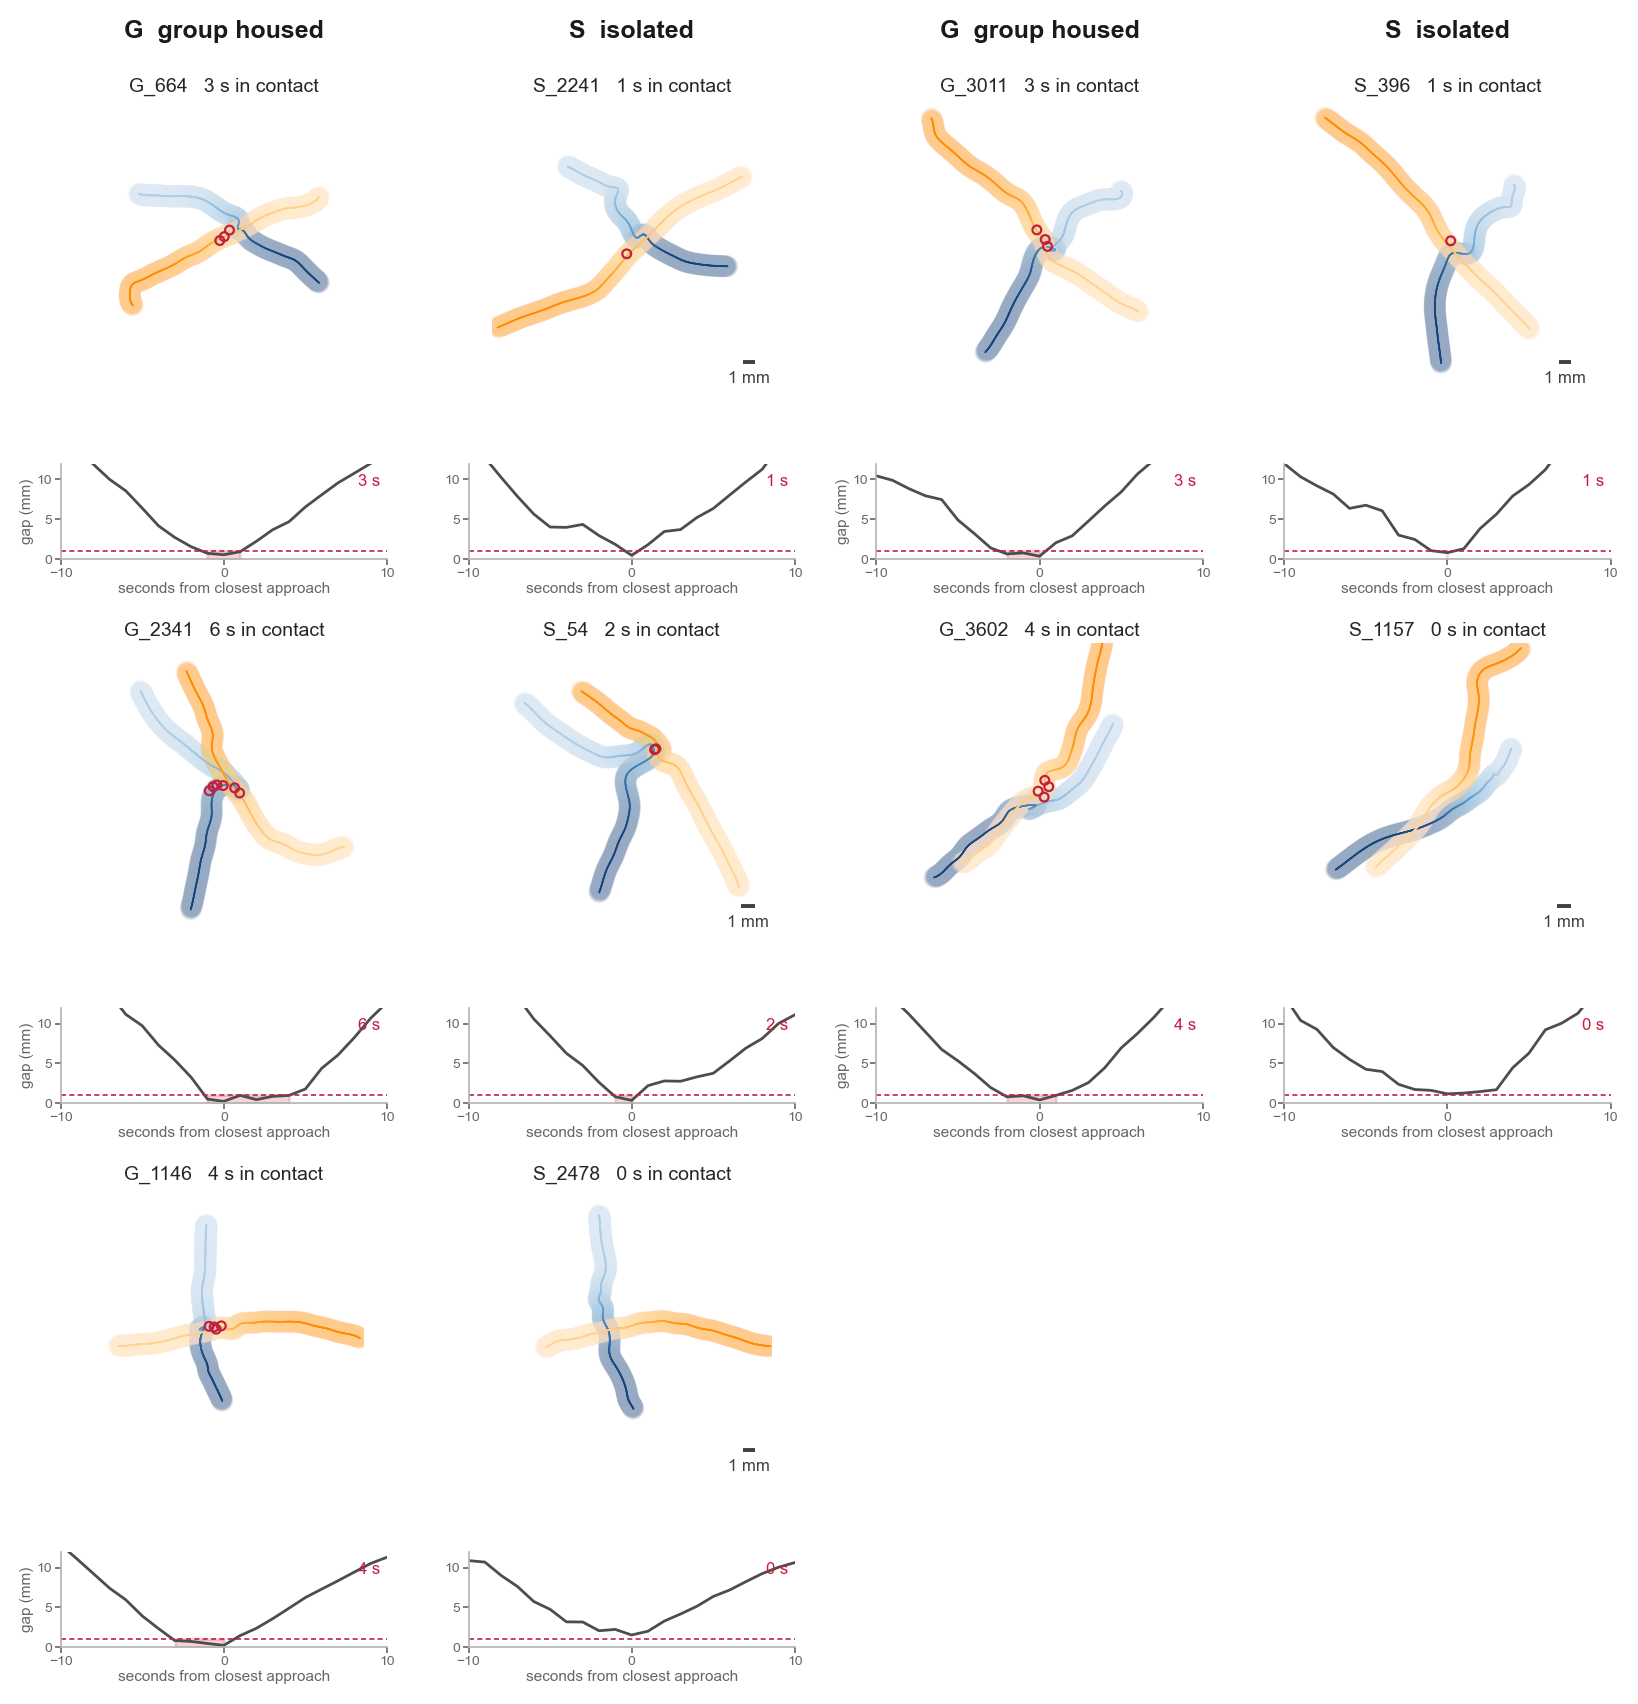

In [175]:
## THE GRID -- TRAJECTORIES WITH THE GAP OVER TIME UNDERNEATH

%config InlineBackend.figure_format = 'retina'


def draw_chosen_pairs():
    PER_ROW = 2
    PANEL_IN = 2.5
    ROW_IN = 3.35
    PAD_MM = 1.5
    NAME = 'chosen-pairs'

    nrows = int(np.ceil(len(sel) / PER_ROW))
    fig = plt.figure(figsize=(PANEL_IN * 2 * PER_ROW, ROW_IN * nrows))
    gs = fig.add_gridspec(nrows * 2, 2 * PER_ROW, height_ratios=[1, 0.34] * nrows,
                          hspace=0.45, wspace=0.25)

    for k, (_, row) in enumerate(sel.iterrows()):
        r, blk = divmod(k, PER_ROW)
        g_ex, g_cub = cube_of(row.G_id)
        s_ex, s_raw = cube_of(row.S_id)
        cub = {row.G_id: g_cub, row.S_id: align_onto(s_raw, g_cub, int(row.swap))}
        exd = {row.G_id: g_ex, row.S_id: s_ex}
        paths = {i: [smooth_from_cube(exd[i], cub[i], tr) for tr in (0, 1)] for i in cub}
        allp = np.vstack([np.vstack(p) for p in paths.values()])
        cx, cy = allp[:, 0].mean(), allp[:, 1].mean()
        half = (max(np.ptp(allp[:, 0]), np.ptp(allp[:, 1])) + 2 * PAD_MM) / 2

        for c, (iid, lab, nc) in enumerate([(row.G_id, 'G  group housed', row.G_contact),
                                            (row.S_id, 'S  isolated', row.S_contact)]):
            ax = fig.add_subplot(gs[r * 2, blk * 2 + c])
            for tr in (0, 1):
                trace_pts(ax, paths[iid][tr], tr + 1)
            marks_from_cube(ax, exd[iid], cub[iid])
            ax.set_xlim(cx - half, cx + half); ax.set_ylim(cy - half, cy + half)
            ax.set_aspect('equal'); ax.axis('off')
            ax.set_title(f'{iid}   {nc} s in contact', fontsize=7, color='0.15', pad=3)
            if r == 0:
                ax.text(0.5, 1.22, lab, transform=ax.transAxes, ha='center',
                        fontsize=9, color='0.1', weight='bold')
            if c == 1:
                scale_bar(ax)

            axg = fig.add_subplot(gs[r * 2 + 1, blk * 2 + c])
            gap_strip(axg, exd[iid], nc)
            if c == 0:
                axg.set_ylabel('gap (mm)', fontsize=5.5, color='0.4', labelpad=1)
            axg.set_xlabel('seconds from closest approach', fontsize=5.5, color='0.4', labelpad=1)

    for ext in ('pdf',):
        fig.savefig(os.path.join(OUT_DIR, f'{NAME}.{ext}'), bbox_inches='tight')
    plt.show()


draw_chosen_pairs()

In [176]:
## FIND A BETTER S PARTNER FOR ONE G

def better_match():
    G_ID = 'G_2341'
    MIN_GAP = 2            # seconds of contact the G must have over its S partner
    MIN_S_CONTACT = 1      # the S partner has to touch too
    SEP_MM = 2.0           # both larvae this far apart at the window edges
    MIN_STRAIGHT = 0.60    # net / total on the drawn path -- not doubling back
    WORST_TURN = 130.0     # deg in the sharpest single second
    DPROF_TOL = 1.4        # mm; distance-vs-frame curves must agree on the fit frames
    N_SHOW = 10
    TYPE_CLASS = {'head-head': 'head-head', 'head-tail': 'head-tail', 'tail-head': 'head-tail',
                  'body-head': 'body-head', 'head-body': 'body-head'}

    cols = [f'mm_Track_{t} {a}_{n}' for t in (1, 2) for n in NODES for a in ('x', 'y')]
    roll = lambda a: pd.DataFrame(a).rolling(SMOOTH_WIN, center=True, min_periods=1).mean().values

    def turn_quality(cub):
        worst, straight = 0.0, 1.0
        for k in (0, 1):
            pth = (1 - BODY_MIX) * roll(cub[:, k, 0, :]) + BODY_MIX * roll(cub[:, k, 1, :])
            st = np.diff(pth, axis=0)
            length = np.linalg.norm(st, axis=1).sum()
            straight = min(straight, np.linalg.norm(pth[-1] - pth[0]) / length if length > 0 else 0)
            c = (st[:-1] * st[1:]).sum(1) / (np.linalg.norm(st[:-1], axis=1) * np.linalg.norm(st[1:], axis=1) + 1e-12)
            worst = max(worst, np.degrees(np.arccos(np.clip(c, -1, 1))).max())
        return straight, worst

    g_ex, g_cub = cube_of(G_ID)
    g_prof = g_ex['min_distance'].values
    g_con = int((g_prof < CONTACT_DIST).sum())
    g_cls = TYPE_CLASS.get(g_ex['interaction_type'].iloc[0], g_ex['interaction_type'].iloc[0])
    A = g_cub[FIT_MASK].reshape(-1, 2)

    out = []
    for iid, s in df[df['condition'] == 'S'].groupby('interaction_id', sort=False):
        s = s.set_index('Normalized Frame').reindex(FRAMES)
        if s[cols].isna().any().any():
            continue
        cls = TYPE_CLASS.get(s['interaction_type'].iloc[10], s['interaction_type'].iloc[10])
        if cls != g_cls:
            continue
        prof = s['min_distance'].values
        ncon = int((prof < CONTACT_DIST).sum())
        if ncon < MIN_S_CONTACT or g_con - ncon < MIN_GAP or prof[0] < SEP_MM or prof[-1] < SEP_MM:
            continue
        derr = np.abs(g_prof[FIT_MASK] - prof[FIT_MASK]).mean()
        if derr > DPROF_TOL:
            continue
        cub = s[cols].values.reshape(len(FRAMES), 2, len(NODES), 2)
        cub = cub - cub[10, :, 1, :].mean(0)
        straight, worst = turn_quality(cub)
        if straight < MIN_STRAIGHT or worst > WORST_TURN:
            continue
        rmsd, swap = min((fit(A, b[FIT_MASK].reshape(-1, 2))[0], sw)
                         for sw, b in ((0, cub), (1, cub[:, ::-1])))
        out.append(dict(S_id=iid, S_type=s['interaction_type'].iloc[10], rmsd=rmsd, dprof_err=derr,
                        G_contact=g_con, S_contact=ncon, swap=swap,
                        min_straight=straight, worst_turn=worst))

    o = pd.DataFrame(out).sort_values('rmsd').head(N_SHOW).reset_index(drop=True)
    current = sel.loc[sel['G_id'] == G_ID, 'rmsd']
    if len(current):
        print(f'current partner RMSD: {current.iloc[0]:.2f} mm')
    return o


alt = better_match()
alt.round(2)

current partner RMSD: 2.19 mm


,S_id,S_type,rmsd,dprof_err,G_contact,S_contact,swap,min_straight,worst_turn
0,S_96,head-head,1.70,0.72,6,2,1,0.76,55.52
1,S_1331,head-head,1.79,1.06,6,1,1,0.92,128.39
2,S_1289,head-head,1.91,1.36,6,1,1,0.75,76.33
3,S_54,head-head,2.19,1.16,6,2,0,0.71,115.36
4,S_31,head-head,2.53,1.37,6,1,0,0.61,99.43
5,S_1085,head-head,2.58,0.81,6,4,0,0.85,72.06
6,S_3329,head-head,3.13,1.33,6,1,0,0.95,25.24
7,S_739,head-head,3.28,1.26,6,4,0,0.95,30.72
8,S_1681,head-head,3.39,1.17,6,2,0,0.93,102.38
9,S_713,head-head,3.82,1.06,6,3,0,0.85,31.40


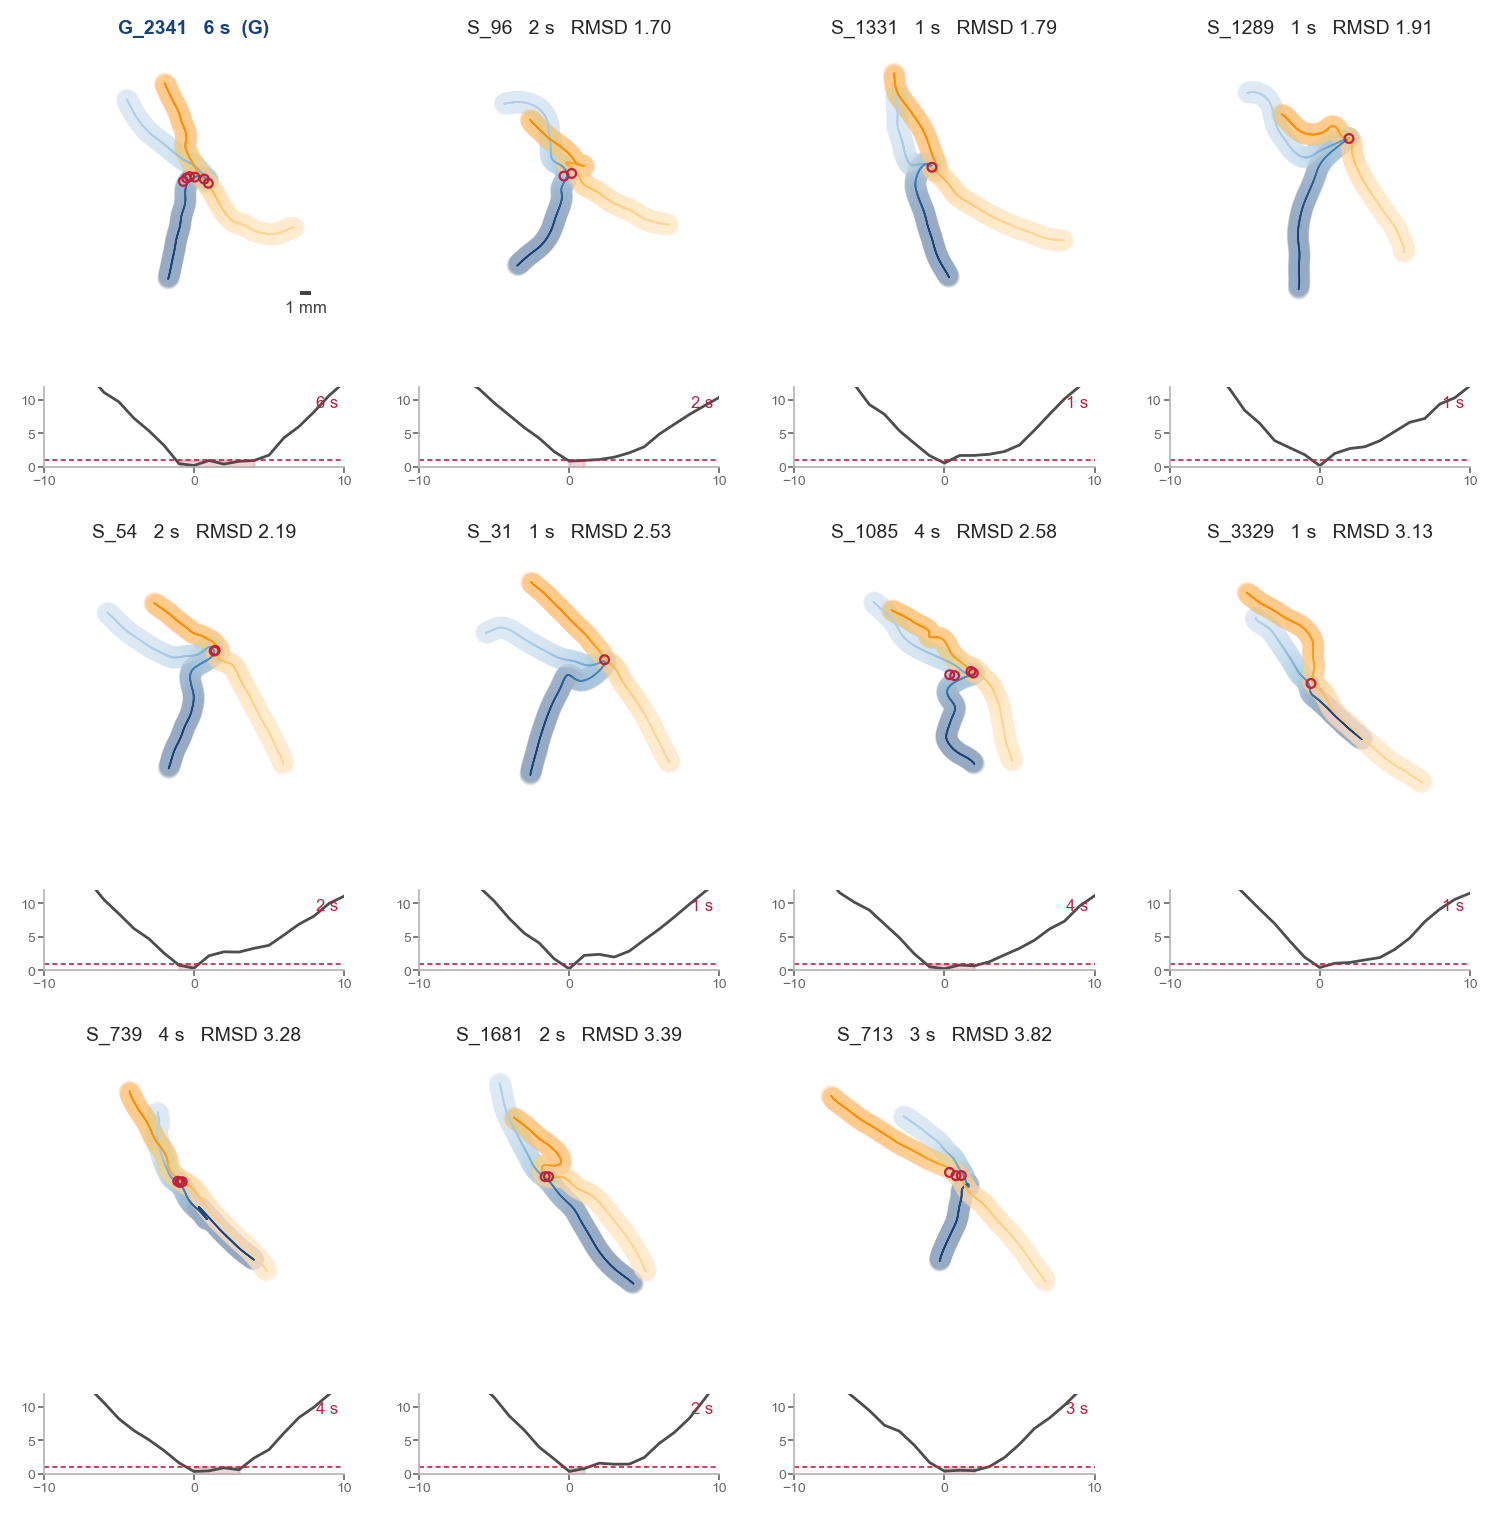

In [177]:
## LOOK AT THE CANDIDATES -- G first, then each S rotated into G's frame

%config InlineBackend.figure_format = 'retina'


def draw_candidates():
    G_ID = 'G_2341'
    NCOLS = 4
    PANEL_IN = 2.3
    ROW_IN = 3.1
    PAD_MM = 1.5

    g_ex, g_cub = cube_of(G_ID)
    items = [(G_ID, g_ex, g_cub, f'{G_ID}   {int((g_ex["min_distance"] < CONTACT_DIST).sum())} s  (G)')]
    for _, row in alt.iterrows():
        s_ex, s_raw = cube_of(row.S_id)
        items.append((row.S_id, s_ex, align_onto(s_raw, g_cub, int(row.swap)),
                      f'{row.S_id}   {row.S_contact} s   RMSD {row.rmsd:.2f}'))

    paths = [[smooth_from_cube(ex, cub, tr) for tr in (0, 1)] for _, ex, cub, _ in items]
    allp = np.vstack([np.vstack(p) for p in paths])
    cx, cy = allp[:, 0].mean(), allp[:, 1].mean()
    half = (max(np.ptp(allp[:, 0]), np.ptp(allp[:, 1])) + 2 * PAD_MM) / 2

    nrows = int(np.ceil(len(items) / NCOLS))
    fig = plt.figure(figsize=(PANEL_IN * NCOLS, ROW_IN * nrows))
    gs = fig.add_gridspec(nrows * 2, NCOLS, height_ratios=[1, 0.3] * nrows, hspace=0.45, wspace=0.25)

    for k, ((iid, ex, cub, title), pth) in enumerate(zip(items, paths)):
        r, c = divmod(k, NCOLS)
        ax = fig.add_subplot(gs[r * 2, c])
        for tr in (0, 1):
            trace_pts(ax, pth[tr], tr + 1)
        marks_from_cube(ax, ex, cub)
        ax.set_xlim(cx - half, cx + half); ax.set_ylim(cy - half, cy + half)
        ax.set_aspect('equal'); ax.axis('off')
        ax.set_title(title, fontsize=7, color='#17427a' if k == 0 else '0.15', pad=3,
                     weight='bold' if k == 0 else 'normal')
        if k == 0:
            scale_bar(ax)
        gap_strip(fig.add_subplot(gs[r * 2 + 1, c]), ex, int((ex['min_distance'] < CONTACT_DIST).sum()))

    plt.show()


draw_candidates()

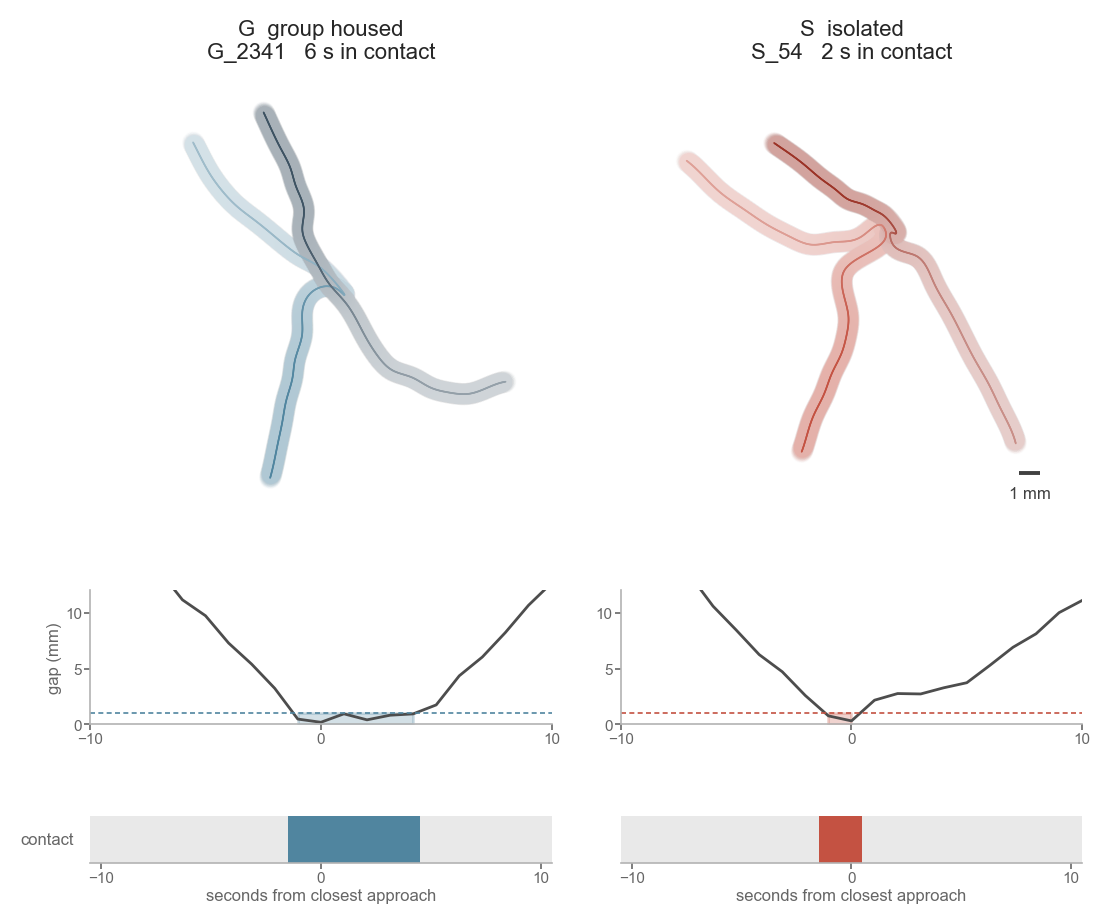

In [178]:
## JUST G_2341 AND S_54 -- SIDE BY SIDE, ONE COLOUR PER CONDITION

%config InlineBackend.figure_format = 'retina'

G_COLOUR = '#50859f'     # larva 1, group-housed panel
G_COLOUR_2 = '#3d5262'   # larva 2, group-housed panel
S_COLOUR = '#c45242'     # larva 1, isolated panel
S_COLOUR_2 = '#9c3327'   # larva 2, isolated panel


def cond_cmap(base_hex):
    """pale -> base_hex exactly: the end of every trace is the colour you picked"""
    PALE_MIX = 0.45   # how much white the start of the ramp mixes in
    base = np.array([int(base_hex[i:i + 2], 16) / 255 for i in (1, 3, 5)])
    pale = base + (1 - base) * PALE_MIX
    return LinearSegmentedColormap.from_list(base_hex, [pale, base])


# (condition, track) -> colormap
CMAPS_COND = {('G', 0): cond_cmap(G_COLOUR), ('G', 1): cond_cmap(G_COLOUR_2),
              ('S', 0): cond_cmap(S_COLOUR), ('S', 1): cond_cmap(S_COLOUR_2)}


def trace_cond(ax, pts, cmap):
    """same treatment as trace_pts(), but the colour comes from the condition, not the track"""
    xy, t = spline(pts)
    segs = np.stack([xy[:-1], xy[1:]], axis=1)
    cols = cmap(ramp(t[:-1]))
    pale = lighten(cols)
    for w in np.linspace(HALO_W, CORE_LW * 1.5, N_HALO):
        ax.add_collection(LineCollection(segs, colors=pale, linewidths=w, alpha=HALO_ALPHA,
                                         capstyle='round', joinstyle='round', zorder=2))
    ax.add_collection(LineCollection(segs, colors=cols, linewidths=CORE_LW,
                                     capstyle='round', joinstyle='round', zorder=3))


def strip_gap(ax, d, colour):
    """the gap over time -- how close they get, and for how long they stay under 1 mm"""
    Y_MAX = 12
    ax.plot(FRAMES, d, color='0.3', lw=1.0)
    ax.axhline(CONTACT_DIST, color=colour, lw=0.6, ls=(0, (3, 2)))
    ax.fill_between(FRAMES, 0, CONTACT_DIST, where=d < CONTACT_DIST, color=colour, alpha=0.25)
    ax.set_ylim(0, Y_MAX); ax.set_xlim(-10, 10)
    ax.set_yticks([0, 5, 10]); ax.set_xticks([-10, 0, 10])
    ax.tick_params(labelsize=5.5, length=2, pad=1, colors='0.4')
    for sp in ('top', 'right'):
        ax.spines[sp].set_visible(False)
    for sp in ('left', 'bottom'):
        ax.spines[sp].set_color('0.7'); ax.spines[sp].set_linewidth(0.6)


def strip_etho(ax, d, colour):
    """contact / no contact, one block per second"""
    NO_CONTACT = '#e9e9e9'
    for f, touching in zip(FRAMES, d < CONTACT_DIST):
        ax.axvspan(f - 0.5, f + 0.5, color=colour if touching else NO_CONTACT, lw=0)
    ax.set_xlim(-10.5, 10.5); ax.set_ylim(0, 1)
    ax.set_yticks([]); ax.set_xticks([-10, 0, 10])
    ax.tick_params(labelsize=5.5, length=2, pad=1, colors='0.4')
    for sp in ('top', 'right', 'left'):
        ax.spines[sp].set_visible(False)
    ax.spines['bottom'].set_color('0.7'); ax.spines['bottom'].set_linewidth(0.6)


def draw_one_pair():
    G_ID = 'G_2341'
    S_ID = 'S_54'
    PANEL_IN = 3.2
    PAD_MM = 1.5
    GAP_IN = 1.0      # height of the min-distance row
    ETHO_IN = 0.35    # height of the contact / no contact row
    NAME = 'G2341-S54'

    g_ex, g_cub = cube_of(G_ID)
    s_ex, s_raw = cube_of(S_ID)
    A = g_cub[FIT_MASK].reshape(-1, 2)
    _, swap = min((fit(A, b[FIT_MASK].reshape(-1, 2))[0], sw)
                  for sw, b in ((0, s_raw), (1, s_raw[:, ::-1])))
    cub = {G_ID: g_cub, S_ID: align_onto(s_raw, g_cub, swap)}
    exd = {G_ID: g_ex, S_ID: s_ex}

    paths = {i: [smooth_from_cube(exd[i], cub[i], tr) for tr in (0, 1)] for i in cub}
    allp = np.vstack([np.vstack(p) for p in paths.values()])
    cx, cy = allp[:, 0].mean(), allp[:, 1].mean()
    half = (max(np.ptp(allp[:, 0]), np.ptp(allp[:, 1])) + 2 * PAD_MM) / 2

    fig = plt.figure(figsize=(PANEL_IN * 2, PANEL_IN + GAP_IN + ETHO_IN + 0.6))
    gs = fig.add_gridspec(3, 2, height_ratios=[PANEL_IN, GAP_IN, ETHO_IN],
                          hspace=0.45, wspace=0.15)

    for col, (iid, lab) in enumerate([(G_ID, 'G  group housed'), (S_ID, 'S  isolated')]):
        colour = {'G': G_COLOUR, 'S': S_COLOUR}[iid[0]]
        d = exd[iid].sort_values('Normalized Frame')['min_distance'].values
        nc = int((d < CONTACT_DIST).sum())

        # ROW 1 -- the interaction, exactly as before
        ax = fig.add_subplot(gs[0, col])
        for tr, p in enumerate(paths[iid]):
            trace_cond(ax, p, CMAPS_COND[(iid[0], tr)])
        ax.set_xlim(cx - half, cx + half); ax.set_ylim(cy - half, cy + half)
        ax.set_aspect('equal'); ax.axis('off')
        ax.set_title(f'{lab}\n{iid}   {nc} s in contact', fontsize=8, color='0.15', pad=4)
        if col == 1:
            scale_bar(ax)

        # ROW 2 -- the gap over time
        ax_gap = fig.add_subplot(gs[1, col])
        strip_gap(ax_gap, d, colour)
        if col == 0:
            ax_gap.set_ylabel('gap (mm)', fontsize=6, color='0.4', labelpad=1)

        # ROW 3 -- contact / no contact, one block per second
        ax_eth = fig.add_subplot(gs[2, col])
        strip_etho(ax_eth, d, colour)
        if col == 0:
            ax_eth.set_ylabel('contact', fontsize=6, color='0.4', labelpad=6,
                              rotation=0, ha='right', va='center')
        ax_eth.set_xlabel('seconds from closest approach', fontsize=6, color='0.4', labelpad=1)

    fig.savefig(os.path.join(OUT_DIR, f'{NAME}.pdf'), bbox_inches='tight')
    plt.show()


draw_one_pair()


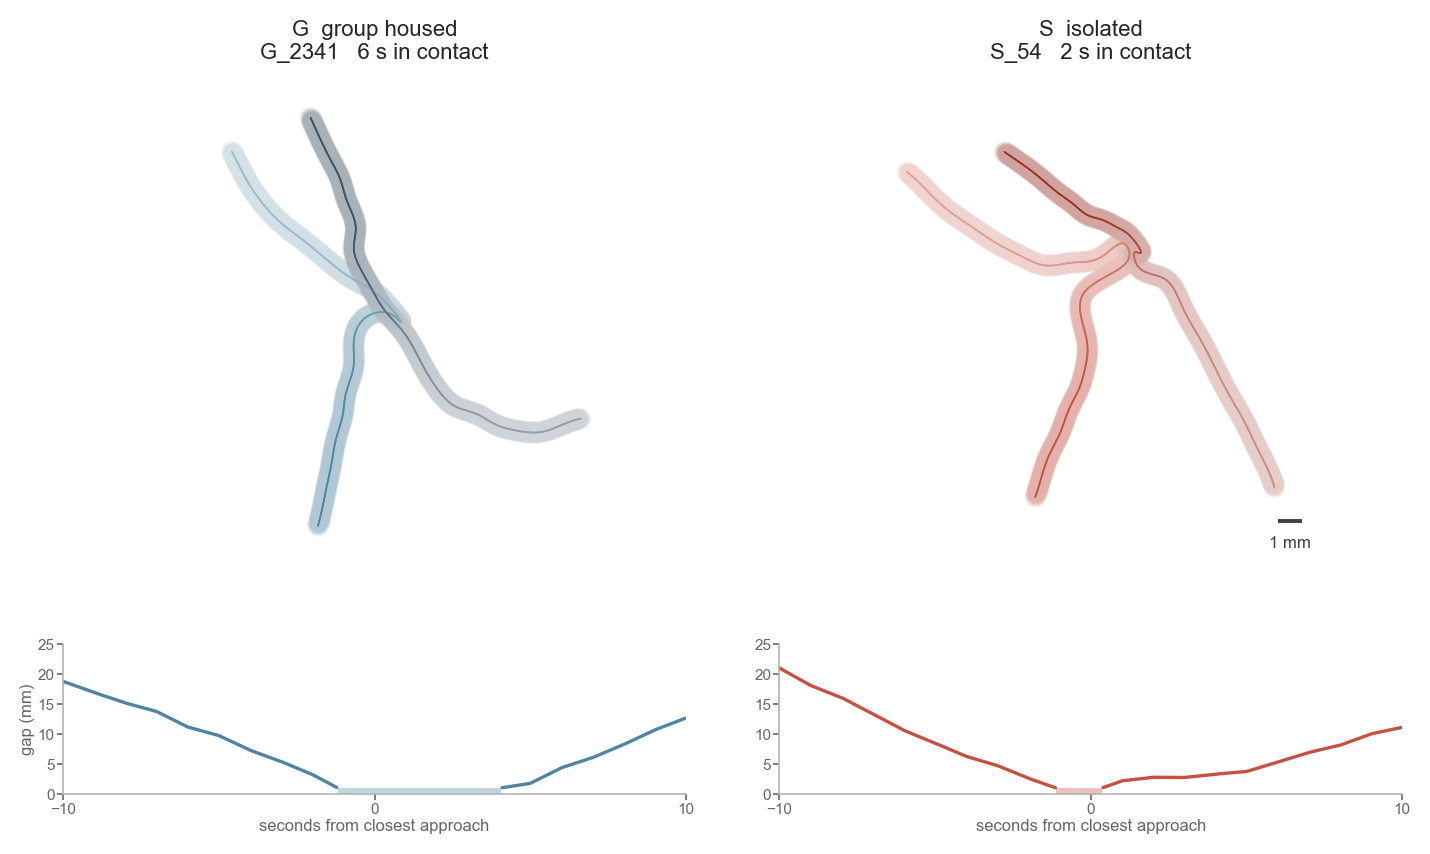

In [179]:
## SAME PAIR -- INTERACTION ON TOP, JUST THE DISTANCE PLOT UNDERNEATH

%config InlineBackend.figure_format = 'retina'


def strip_distance(ax, d, colour, y_max):
    """gap over time in the panel's own colour; the line stops where contact starts,
    so the shaded block is the only thing marking contact"""
    FILL_ALPHA = 0.35
    N_FINE = 800   # sub-second sampling so the line meets the block exactly at 1 mm
    x = np.linspace(FRAMES[0], FRAMES[-1], N_FINE)
    y = np.interp(x, FRAMES, d)
    touching = y < CONTACT_DIST
    ax.plot(x, np.where(touching, np.nan, y), color=colour, lw=1.2, solid_capstyle='round')
    ax.fill_between(x, 0, CONTACT_DIST, where=touching, color=colour,
                    alpha=FILL_ALPHA, lw=0)
    ax.set_ylim(0, y_max); ax.set_xlim(-10, 10)
    ax.set_yticks(np.arange(0, y_max + 1, 5)); ax.set_xticks([-10, 0, 10])
    ax.tick_params(labelsize=5.5, length=2, pad=1, colors='0.4')
    for sp in ('top', 'right'):
        ax.spines[sp].set_visible(False)
    for sp in ('left', 'bottom'):
        ax.spines[sp].set_color('0.7'); ax.spines[sp].set_linewidth(0.6)


def draw_pair_distance():
    G_ID = 'G_2341'
    S_ID = 'S_54'
    PANEL_IN = 3.2
    PAD_MM = 1.5
    GAP_IN = 1.0      # height of the min-distance row
    WIDE = 1.35       # stretches the figure sideways -- traces keep their shape, the gap plots widen
    NAME = 'G2341-S54_distance'

    g_ex, g_cub = cube_of(G_ID)
    s_ex, s_raw = cube_of(S_ID)
    A = g_cub[FIT_MASK].reshape(-1, 2)
    _, swap = min((fit(A, b[FIT_MASK].reshape(-1, 2))[0], sw)
                  for sw, b in ((0, s_raw), (1, s_raw[:, ::-1])))
    cub = {G_ID: g_cub, S_ID: align_onto(s_raw, g_cub, swap)}
    exd = {G_ID: g_ex, S_ID: s_ex}

    paths = {i: [smooth_from_cube(exd[i], cub[i], tr) for tr in (0, 1)] for i in cub}
    allp = np.vstack([np.vstack(p) for p in paths.values()])
    cx, cy = allp[:, 0].mean(), allp[:, 1].mean()
    half = (max(np.ptp(allp[:, 0]), np.ptp(allp[:, 1])) + 2 * PAD_MM) / 2

    dist = {i: exd[i].sort_values('Normalized Frame')['min_distance'].values for i in cub}
    y_max = float(np.ceil(max(v.max() for v in dist.values()) / 5) * 5)

    fig = plt.figure(figsize=(PANEL_IN * 2 * WIDE, PANEL_IN + GAP_IN + 0.5))
    gs = fig.add_gridspec(2, 2, height_ratios=[PANEL_IN, GAP_IN], hspace=0.3, wspace=0.15)

    for col, (iid, lab) in enumerate([(G_ID, 'G  group housed'), (S_ID, 'S  isolated')]):
        colour = {'G': G_COLOUR, 'S': S_COLOUR}[iid[0]]
        d = dist[iid]
        nc = int((d < CONTACT_DIST).sum())

        ax = fig.add_subplot(gs[0, col])
        for tr, p in enumerate(paths[iid]):
            trace_cond(ax, p, CMAPS_COND[(iid[0], tr)])
        ax.set_xlim(cx - half, cx + half); ax.set_ylim(cy - half, cy + half)
        ax.set_aspect('equal'); ax.axis('off')
        ax.set_title(f'{lab}\n{iid}   {nc} s in contact', fontsize=8, color='0.15', pad=4)
        if col == 1:
            scale_bar(ax)

        ax_gap = fig.add_subplot(gs[1, col])
        strip_distance(ax_gap, d, colour, y_max)
        if col == 0:
            ax_gap.set_ylabel('gap (mm)', fontsize=6, color='0.4', labelpad=1)
        ax_gap.set_xlabel('seconds from closest approach', fontsize=6, color='0.4', labelpad=1)

    fig.savefig(os.path.join(OUT_DIR, f'{NAME}.pdf'), bbox_inches='tight')
    plt.show()


draw_pair_distance()


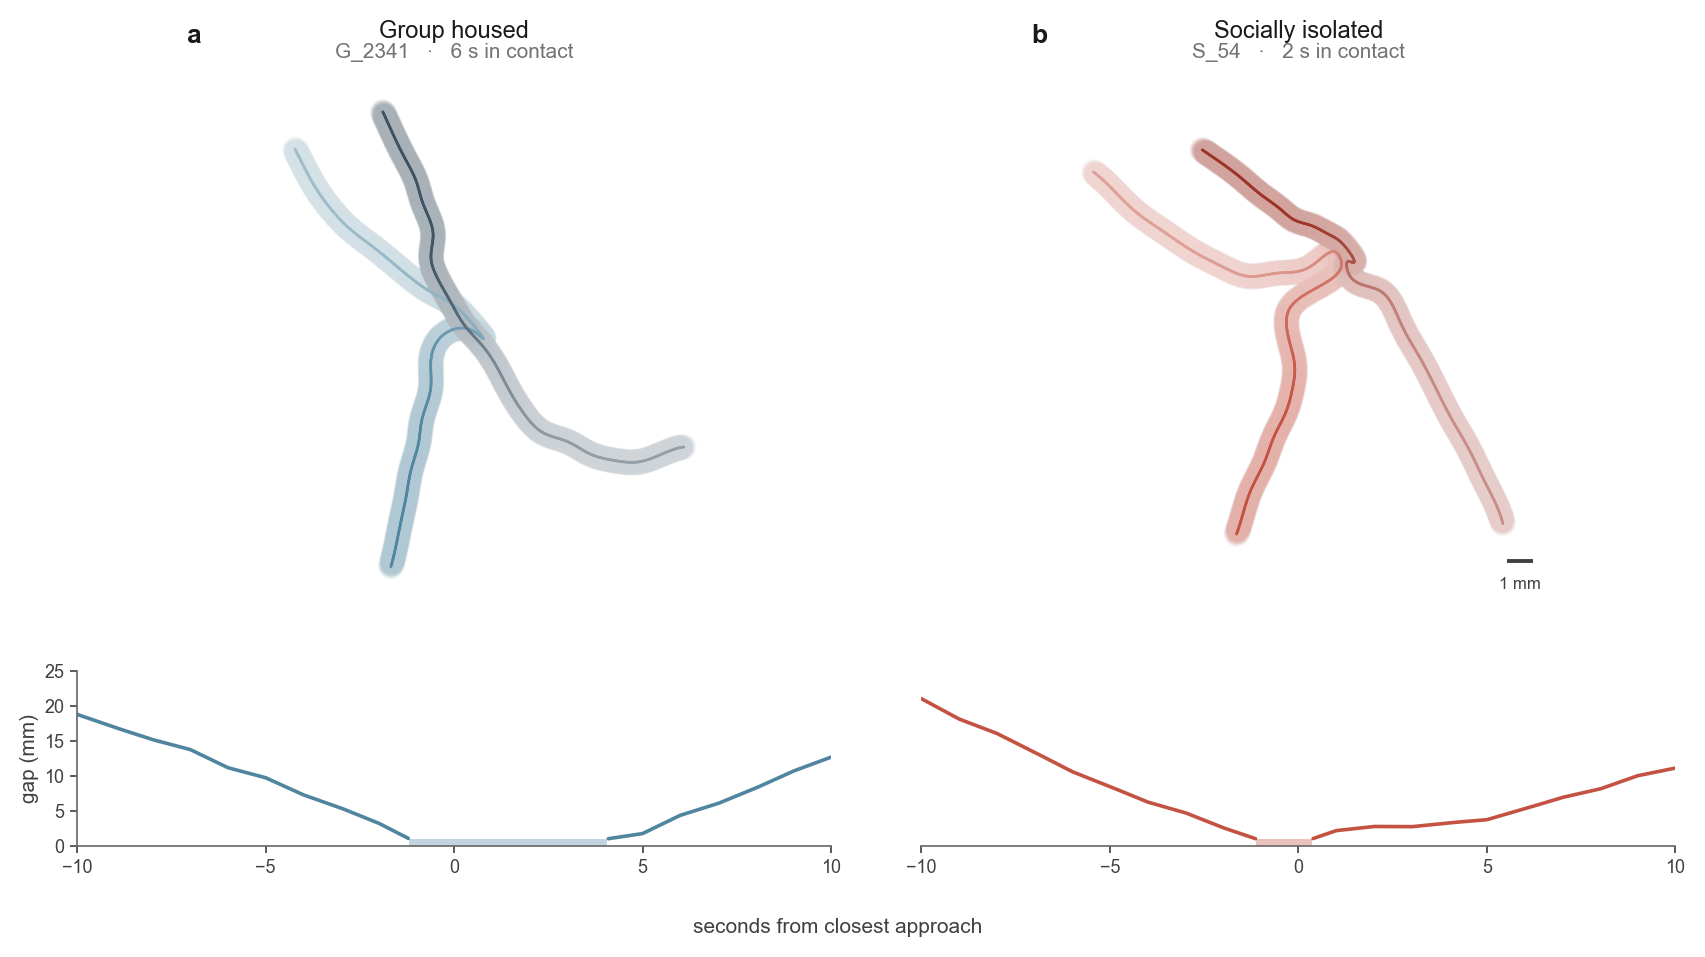

In [180]:
## FIGURE PANEL -- G_2341 vs S_54, TRAJECTORIES OVER THE GAP THEY KEEP

%config InlineBackend.figure_format = 'retina'

mpl.rcParams.update({'pdf.fonttype': 42, 'ps.fonttype': 42, 'svg.fonttype': 'none',
                     'font.family': 'sans-serif', 'font.sans-serif': ['Arial'],
                     'axes.linewidth': 0.6, 'xtick.major.width': 0.6,
                     'ytick.major.width': 0.6, 'savefig.transparent': False})


def strip_distance(ax, d, colour, y_max, show_y):
    """gap over time in the panel's own colour; the line stops at 1 mm and the
    shaded block carries the contact, so nothing is drawn twice"""
    FILL_ALPHA = 0.35
    N_FINE = 800    # sub-second sampling so the line meets the block exactly at 1 mm
    TICK_FS = 6.5
    LAB_FS = 7.5

    x = np.linspace(FRAMES[0], FRAMES[-1], N_FINE)
    y = np.interp(x, FRAMES, d)
    touching = y < CONTACT_DIST
    ax.plot(x, np.where(touching, np.nan, y), color=colour, lw=1.3, solid_capstyle='round')
    ax.fill_between(x, 0, CONTACT_DIST, where=touching, color=colour,
                    alpha=FILL_ALPHA, lw=0)

    ax.set_ylim(0, y_max); ax.set_xlim(-10, 10)
    ax.set_xticks([-10, -5, 0, 5, 10])
    ax.tick_params(labelsize=TICK_FS, length=2.5, width=0.6, pad=2,
                   colors='0.25', direction='out')
    for sp in ('top', 'right'):
        ax.spines[sp].set_visible(False)
    ax.spines['bottom'].set_color('0.4')

    if show_y:
        ax.set_yticks(np.arange(0, y_max + 1, 5))
        ax.spines['left'].set_color('0.4')
        ax.set_ylabel('gap (mm)', fontsize=LAB_FS, color='0.25', labelpad=2)
    else:
        ax.set_yticks([])
        ax.spines['left'].set_visible(False)


def trace_thick(ax, pts, cmap):
    """as trace_cond(), with its own weights so the paper figure can run heavier
    than the browsing panels above"""
    LW = 0.95        # the core line (0.6 in the panels above)
    HALO = 9.5       # outer width of the soft band
    HALO_A = 0.05    # per-layer alpha of that band
    xy, t = spline(pts)
    segs = np.stack([xy[:-1], xy[1:]], axis=1)
    cols = cmap(ramp(t[:-1]))
    pale = lighten(cols)
    for w in np.linspace(HALO, LW * 1.5, N_HALO):
        ax.add_collection(LineCollection(segs, colors=pale, linewidths=w, alpha=HALO_A,
                                         capstyle='round', joinstyle='round', zorder=2))
    ax.add_collection(LineCollection(segs, colors=cols, linewidths=LW,
                                     capstyle='round', joinstyle='round', zorder=3))


def draw_figure_panel():
    G_ID = 'G_2341'
    S_ID = 'S_54'
    PANEL_IN = 3.2      # height of the trajectory row
    WIDE = 1.35         # sideways stretch; traces keep their shape, the gap plots widen
    GAP_IN = 1.05       # height of the distance row
    PAD_MM = 1.5
    LETTER_FS = 9.5
    LAB_FS = 8.5
    SUB_FS = 7.5
    DPI = 600
    NAME = 'G2341-S54_figure'

    g_ex, g_cub = cube_of(G_ID)
    s_ex, s_raw = cube_of(S_ID)
    A = g_cub[FIT_MASK].reshape(-1, 2)
    _, swap = min((fit(A, b[FIT_MASK].reshape(-1, 2))[0], sw)
                  for sw, b in ((0, s_raw), (1, s_raw[:, ::-1])))
    cub = {G_ID: g_cub, S_ID: align_onto(s_raw, g_cub, swap)}
    exd = {G_ID: g_ex, S_ID: s_ex}

    paths = {i: [smooth_from_cube(exd[i], cub[i], tr) for tr in (0, 1)] for i in cub}
    allp = np.vstack([np.vstack(p) for p in paths.values()])
    cx, cy = allp[:, 0].mean(), allp[:, 1].mean()
    half = (max(np.ptp(allp[:, 0]), np.ptp(allp[:, 1])) + 2 * PAD_MM) / 2

    dist = {i: exd[i].sort_values('Normalized Frame')['min_distance'].values for i in cub}
    y_max = float(np.ceil(max(v.max() for v in dist.values()) / 5) * 5)

    fig = plt.figure(figsize=(PANEL_IN * 2 * WIDE, PANEL_IN + GAP_IN + 0.55))
    gs = fig.add_gridspec(2, 2, height_ratios=[PANEL_IN, GAP_IN],
                          hspace=0.22, wspace=0.12,
                          left=0.06, right=0.985, top=0.93, bottom=0.11)

    for col, (iid, letter, lab) in enumerate([(G_ID, 'a', 'Group housed'),
                                              (S_ID, 'b', 'Socially isolated')]):
        colour = {'G': G_COLOUR, 'S': S_COLOUR}[iid[0]]
        d = dist[iid]
        nc = int((d < CONTACT_DIST).sum())

        # --- trajectories
        ax = fig.add_subplot(gs[0, col])
        for tr, p in enumerate(paths[iid]):
            trace_thick(ax, p, CMAPS_COND[(iid[0], tr)])
        ax.set_xlim(cx - half, cx + half); ax.set_ylim(cy - half, cy + half)
        ax.set_aspect('equal'); ax.axis('off')
        ax.text(0.0, 1.02, letter, transform=ax.transAxes, ha='left', va='bottom',
                fontsize=LETTER_FS, fontweight='bold', color='0.1')
        ax.text(0.5, 1.03, lab, transform=ax.transAxes, ha='center', va='bottom',
                fontsize=LAB_FS, color='0.1')
        ax.text(0.5, 0.995, f'{iid}   ·   {nc} s in contact', transform=ax.transAxes,
                ha='center', va='bottom', fontsize=SUB_FS, color='0.45')
        if col == 1:
            scale_bar(ax)

        # --- the gap they keep
        ax_gap = fig.add_subplot(gs[1, col])
        strip_distance(ax_gap, d, colour, y_max, show_y=(col == 0))

    fig.supxlabel('seconds from closest approach', fontsize=SUB_FS, color='0.25', y=0.015)

    fig.savefig(os.path.join(OUT_DIR, f'{NAME}.pdf'), bbox_inches='tight')

    plt.show()


draw_figure_panel()
